# 02 — Exit liquidity

Provenance first: the cell below reads this loop's `manifest.json` and prints it.
If it raises, record provenance before computing anything.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from metron import empirical_survival, hhi, occupancy_below, spell_stats

from mrsearch import SnapshotReader, read_manifest

manifest = read_manifest(Path.cwd())
print(manifest)

r = SnapshotReader(Path.cwd().parents[1] / "data")
pd.set_option("display.width", 220)


def ts64(s):
    """tz-aware ts Series -> naive-UTC datetime64 array (for searchsorted)."""
    return s.dt.tz_convert("UTC").dt.tz_localize(None).to_numpy()


HORIZONS = [pd.Timedelta(hours=h) for h in (1, 6, 24, 72, 168)]

Manifest(snapshot_date='2026-08-10', mnemon_commit='b50c56c5c57d647d9b6d6d3f33260375879b9277', metron_version='v1.2.0', tables=('market_state', 'markets', 'market_flows', 'prices', 'supplier_positions'))


## Lane 1 — blocked-spell census

`v_exit_spells` at u >= 0.999 (primary) and u >= 0.99 (sensitivity), full
history. A spell is open when it reaches the market's last sample within
the 2h hole tolerance (the same rule MNEMON's export uses); open spells are
right-censored at the snapshot, never dropped. `duration_min` spans the
first to last above-threshold sample, so a single-sample spell reads 0 —
resolved within one sampling interval. Era stratification: a spell is
live-era when it starts at or after the market's first sub-30-min sampling
gap. METRON `spell_stats` + `empirical_survival` do the estimation.

In [2]:
spells = r.sql("""
    SELECT s.chain_id, s.market_id, s.threshold, s.start_ts, s.end_ts,
           s.duration_min, s.peak_u,
           m.collateral_symbol || '/' || m.loan_symbol AS market,
           lt.mkt_max_ts,
           (s.end_ts >= lt.mkt_max_ts - INTERVAL 2 HOUR) AS open
    FROM v_exit_spells s
    JOIN markets m USING (chain_id, market_id)
    JOIN (SELECT chain_id, market_id, MAX(ts) AS mkt_max_ts
          FROM market_state GROUP BY 1, 2) lt USING (chain_id, market_id)
""")
snapshot_ts = r.sql("SELECT MAX(ts) AS ts FROM market_state").iloc[0, 0]
live_start = r.sql("""
    WITH gaps AS (
        SELECT chain_id, market_id, ts,
               LEAD(ts) OVER (PARTITION BY chain_id, market_id ORDER BY ts) - ts AS gap
        FROM market_state)
    SELECT chain_id, market_id, MIN(ts) AS live_start_ts
    FROM gaps WHERE gap < INTERVAL 30 MINUTE GROUP BY 1, 2
""")
spells = spells.merge(live_start, on=["chain_id", "market_id"], how="left")
spells["era"] = np.where(spells["start_ts"] >= spells["live_start_ts"], "live", "backfill")
spells["duration"] = pd.to_timedelta(spells["duration_min"], unit="m")
spells.loc[spells["open"], "duration"] = snapshot_ts - spells.loc[spells["open"], "start_ts"]
spells["observed"] = ~spells["open"]

t999 = spells[spells["threshold"] == 0.999].reset_index(drop=True)
t990 = spells[spells["threshold"] == 0.990].reset_index(drop=True)
print(
    f"0.999 tier: {len(t999)} spells, {int(t999.open.sum())} open; "
    f"era: {t999.era.value_counts().to_dict()}"
)
print(f"0.990 sensitivity: {len(t990)} spells, {int(t990.open.sum())} open")

print("pooled 0.999:", spell_stats(t999["duration"], t999["observed"]))
pooled_km = empirical_survival(t999["duration"], t999["observed"], HORIZONS)
print("pooled KM S(1h,6h,24h,72h,168h):", [round(float(v), 4) for v in pooled_km])
for era, g in t999.groupby("era"):
    km = empirical_survival(g["duration"], g["observed"], HORIZONS)
    print(f"  {era}: n={len(g)}, S:", [round(float(v), 4) for v in km])
km990 = empirical_survival(t990["duration"], t990["observed"], HORIZONS)
print("0.990 pooled KM:", [round(float(v), 4) for v in km990])

rows = []
for (mid, name), g in t999.groupby(["market_id", "market"]):
    row = {"market": name, "market_id": mid, "n": len(g), "n_open": int(g.open.sum())}
    if g["observed"].any():
        st = spell_stats(g["duration"], g["observed"])
        km = empirical_survival(g["duration"], g["observed"], HORIZONS)
        max_cens = bool(
            g.open.any() and g.loc[g.open, "duration"].max() >= g.loc[g.observed, "duration"].max()
        )
        row |= {
            "median_resolved": st.median_resolved,
            "p90_resolved": st.p90_resolved,
            "S24h": round(float(km.iloc[2]), 3),
            "S168h": round(float(km.iloc[4]), 3),
            "S_lower_bound": max_cens,
        }
    rows.append(row)
census = pd.DataFrame(rows).sort_values("n", ascending=False)
print(census.drop(columns="market_id").head(20).to_string(index=False))

0.999 tier: 3073 spells, 7 open; era: {'backfill': 2381, 'live': 692}
0.990 sensitivity: 3520 spells, 9 open
pooled 0.999: SpellStats(n_total=3073, n_open=7, median_resolved=Timedelta('0 days 00:10:00'), p90_resolved=Timedelta('0 days 12:00:00'), max_resolved=Timedelta('61 days 19:05:00'))
pooled KM S(1h,6h,24h,72h,168h): [0.3559, 0.1648, 0.0522, 0.0168, 0.0069]
  backfill: n=2381, S: [0.4364, 0.1982, 0.0638, 0.0206, 0.0084]
  live: n=692, S: [0.0792, 0.0505, 0.0122, 0.0037, 0.0018]
0.990 pooled KM: [0.3602, 0.1763, 0.057, 0.0169, 0.0079]
       market   n  n_open median_resolved    p90_resolved  S24h  S168h  S_lower_bound
 beHYPE/USD₮0 406       0 0 days 00:05:00 0 days 00:55:00 0.007  0.000          False
    UBTC/USDC 270       2 0 days 00:00:00 0 days 00:05:00 0.000  0.000          False
  kHYPE/USD₮0 130       0 0 days 00:00:00 0 days 09:00:00 0.038  0.008          False
wstHYPE/USD₮0 104       0 0 days 00:00:00 0 days 15:51:00 0.077  0.029          False
   WHYPE/USDC  99       1

In [3]:
# Size-conditional occupancy: METRON occupancy_below (v1.2.0) computes the
# rule-5 time-weighted share of time available liquidity (USD, ASOF-priced
# in v_market_health) sits strictly below each threshold. Rows without a
# price (available_usd NULL) are excluded at extraction.
avail = r.sql("""
    SELECT h.market_id, h.ts, h.available_usd,
           m.collateral_symbol || '/' || m.loan_symbol AS market
    FROM v_market_health h JOIN markets m USING (chain_id, market_id)
    WHERE h.available_usd IS NOT NULL ORDER BY h.market_id, h.ts
""")
THRESHOLDS = [1_000.0, 10_000.0, 100_000.0]
occ_rows = []
for (mid, name), g in avail.groupby(["market_id", "market"]):
    s = g.drop_duplicates(subset="ts").set_index("ts")["available_usd"].astype(float)
    s.index = pd.DatetimeIndex(s.index)
    if len(s) < 100:
        continue
    occ = occupancy_below(s, THRESHOLDS)
    occ_rows.append(
        {
            "market_id": mid,
            "market": name,
            "occ_below_1k": round(float(occ.iloc[0]), 3),
            "occ_below_10k": round(float(occ.iloc[1]), 3),
            "occ_below_100k": round(float(occ.iloc[2]), 3),
        }
    )
occupancy = pd.DataFrame(occ_rows)
print(len(occupancy), "markets have priced availability history")
occ_cols = ["occ_below_1k", "occ_below_10k", "occ_below_100k"]
print(occupancy[occ_cols].describe().round(3).to_string())
print()
print(
    occupancy.sort_values("occ_below_10k", ascending=False)
    .drop(columns="market_id")
    .head(12)
    .to_string(index=False)
)

65 markets have priced availability history
       occ_below_1k  occ_below_10k  occ_below_100k
count        65.000         65.000          65.000
mean          0.162          0.356           0.647
std           0.198          0.298           0.319
min           0.005          0.007           0.016
25%           0.026          0.078           0.439
50%           0.077          0.300           0.722
75%           0.202          0.572           0.963
max           0.870          1.000           1.000

                  market  occ_below_1k  occ_below_10k  occ_below_100k
             kHYPE/USD₮0         0.803          1.000           1.000
            beHYPE/WHYPE         0.870          0.982           1.000
PT-kHYPE-24SEP2026/USD₮0         0.438          0.949           1.000
            wstHYPE/USDe         0.524          0.936           1.000
             hbUSDT/USDe         0.483          0.866           0.995
               sUSDe/USH         0.407          0.864           1.000
      

## Lane 2 — resolution anatomy

IKR filter first: same-tx_hash loan-side Supply/Withdraw pairs equal within
1 bp are Vault V2 in-kind redemptions (exposure transfers, not exits) —
tagged `is_ikr`, excluded from classification inputs, kept for lane 3.

Terminal window: `end_ts` is the last ABOVE-threshold sample, so the
resolving event lies in `(end_ts, next_sample]`; the drafted window
`[end-2h, end]` misses it for 81% of resolved spells (see loop CLAUDE.md).
Window used: `[end-2h, min(next_state_ts, end+2h)]`. Precedence:
liquidation in window; else dominant of net repay vs net new supply;
mixed when the smaller side exceeds 25% of the larger.

In [4]:
flows = r.sql("""
    SELECT ts, market_id, tx_hash, type, account, loan_assets,
           supply_flow, borrow_flow
    FROM v_market_flows
    WHERE type IN ('Supply', 'Withdraw', 'Borrow', 'Repay', 'Liquidation')
    ORDER BY market_id, ts
""")
sw = flows[flows["type"].isin(["Supply", "Withdraw"])]
per_tx = sw.pivot_table(
    index=["market_id", "tx_hash"], columns="type", values="loan_assets", aggfunc="sum"
).fillna(0.0)
both = per_tx[(per_tx["Supply"] > 0) & (per_tx["Withdraw"] > 0)]
mx = both[["Supply", "Withdraw"]].max(axis=1)
ikr_keys = both[(both["Supply"] - both["Withdraw"]).abs() <= 1e-4 * mx].index
flows["is_ikr"] = (
    flows.set_index(["market_id", "tx_hash"]).index.isin(ikr_keys)
    & flows["type"].isin(["Supply", "Withdraw"]).to_numpy()
)
print(
    f"{int(flows.is_ikr.sum())} IKR rows in {len(ikr_keys)} tx pairs; "
    f"{100 * flows.loc[flows.is_ikr, 'loan_assets'].sum() / sw['loan_assets'].sum():.2f}% "
    "of gross Supply+Withdraw volume"
)

nxt = r.sql("""
    SELECT s.market_id, s.start_ts, s.end_ts, MIN(ms.ts) AS next_state_ts
    FROM v_exit_spells s
    JOIN market_state ms ON ms.market_id = s.market_id AND ms.ts > s.end_ts
    WHERE s.threshold = 0.999 GROUP BY 1, 2, 3
""")
res = t999[t999["observed"]].merge(nxt, on=["market_id", "start_ts", "end_ts"], how="left")
res["win_end"] = res["next_state_ts"].clip(upper=res["end_ts"] + pd.Timedelta("2h"))

MIXED_FRACTION = 0.25
flows_by_m = {m: g.reset_index(drop=True) for m, g in flows.groupby("market_id")}


def classify(row):
    g = flows_by_m.get(row.market_id)
    if g is None:
        return "none"
    w = g[(g["ts"] > row.end_ts - pd.Timedelta("2h")) & (g["ts"] <= row.win_end)]
    if (w["type"] == "Liquidation").any():
        return "liquidation"
    wc = w[~w["is_ikr"]]
    repay_mag = max(0.0, -float(wc["borrow_flow"].sum()))
    supply_mag = max(0.0, float(wc["supply_flow"].sum()))
    if repay_mag == 0 and supply_mag == 0:
        return "none"
    small, large = sorted([repay_mag, supply_mag])
    if small > MIXED_FRACTION * large:
        return "mixed"
    return "repay" if repay_mag > supply_mag else "new_supply"


res["mechanism"] = [classify(t) for t in res.itertuples(index=False)]
print(res["mechanism"].value_counts().to_string())
print()
print(res.groupby("era")["mechanism"].value_counts(normalize=True).round(3).to_string())

36345 IKR rows in 18135 tx pairs; 0.74% of gross Supply+Withdraw volume


mechanism
new_supply     1629
none            710
repay           630
liquidation      60
mixed            37

era       mechanism  
backfill  new_supply     0.480
          repay          0.255
          none           0.226
          liquidation    0.024
          mixed          0.015
live      new_supply     0.709
          none           0.252
          repay          0.035
          liquidation    0.003
          mixed          0.001


In [5]:
# IRM-as-exit-pump: rate_at_target at spell start vs end, repay spells only.
ms_rat = r.sql(
    "SELECT market_id, ts, rate_at_target::DOUBLE AS rat FROM market_state ORDER BY market_id, ts"
)
rat_by_m = {m: (ts64(g["ts"]), g["rat"].to_numpy()) for m, g in ms_rat.groupby("market_id")}


def rat_asof(mid, ts):
    a, v = rat_by_m[mid]
    t = pd.Timestamp(ts).tz_convert("UTC").tz_localize(None).to_datetime64()
    i = int(np.searchsorted(a, t, side="right")) - 1
    return v[i] if i >= 0 else np.nan


repay = res[res["mechanism"] == "repay"].copy()
repay["rat_multiple"] = [
    rat_asof(m, e) / rat_asof(m, s)
    for m, s, e in zip(repay.market_id, repay.start_ts, repay.end_ts, strict=True)
]
print("rate_at_target multiple at resolution (repay spells, descriptive):")
print(repay["rat_multiple"].describe().round(3).to_string())
print()
print("elapsed time of repay spells:")
print(repay["duration"].describe().to_string())
# distribution beyond describe() is deferred upstream:
# TODO(metron): add distribution_stats for rate-multiple estimation

rate_at_target multiple at resolution (repay spells, descriptive):
count    630.000
mean       1.144
std        1.492
min        1.000
25%        1.000
50%        1.011
75%        1.041
max       37.270

elapsed time of repay spells:
count                 630
mean      0 days 13:16:09
std       2 days 21:35:18
min       0 days 00:00:00
25%       0 days 00:00:00
50%       0 days 02:00:00
75%       0 days 07:45:00
max      61 days 19:05:00


## Lane 3 — door concentration

Per >= 0.999 spell: (1) METRON `hhi` over non-IKR withdrawal amounts by
account in the spell window ([start, win_end]; open spells run to the
snapshot); (2) `hhi` over the lender book at spell start, reconstructed
from cumulative signed Supply/Withdraw flows per account, each converted
to shares at event time via ASOF `supply_shares / supply_assets` (per-row
algebra). IKR rows stay in the book (ownership transfers) and out of the
withdrawal HHI. Exit-class split: capacity-consuming vs in-kind withdrawn
volume per spell; per-market in-kind share. The supplier_positions overlap
serves as a reconstruction cross-check.

In [6]:
ms_ratio = r.sql("""
    SELECT market_id, ts,
           total_supply_shares::DOUBLE / NULLIF(total_supply_assets::DOUBLE, 0) AS ratio
    FROM market_state ORDER BY market_id, ts
""")
ratio_by_m = {m: (ts64(g["ts"]), g["ratio"].to_numpy()) for m, g in ms_ratio.groupby("market_id")}

book = flows[flows["type"].isin(["Supply", "Withdraw"])].copy().reset_index(drop=True)
book["signed"] = np.where(book["type"] == "Supply", book["loan_assets"], -book["loan_assets"])
shares = np.full(len(book), np.nan)  # stays NaN for never-tracked markets
for m, g in book.groupby("market_id"):
    if m not in ratio_by_m:
        continue  # flows-only market, never tracked in market_state: no spells
    a, v = ratio_by_m[m]
    pos = np.searchsorted(a, ts64(g["ts"]), side="right") - 1
    ratio = np.where(pos >= 0, v[np.clip(pos, 0, None)], np.nan)
    shares[g.index.to_numpy()] = g["signed"].to_numpy() * ratio
book["shares"] = shares
book = book.dropna(subset=["shares"])
book_by_m = {m: g.sort_values("ts") for m, g in book.groupby("market_id")}
wd_by_m = {m: g for m, g in flows[flows["type"] == "Withdraw"].groupby("market_id")}

spells3 = t999.merge(nxt, on=["market_id", "start_ts", "end_ts"], how="left")
spells3["win_end"] = spells3["next_state_ts"].clip(upper=spells3["end_ts"] + pd.Timedelta("2h"))
spells3.loc[spells3["open"], "win_end"] = snapshot_ts


def spell_row(row):
    out = {"market_id": row.market_id, "market": row.market, "start_ts": row.start_ts}
    g = wd_by_m.get(row.market_id)
    w = g[(g["ts"] >= row.start_ts) & (g["ts"] <= row.win_end)] if g is not None else None
    if w is not None and len(w):
        cap = w[~w["is_ikr"]].groupby("account")["loan_assets"].sum()
        cap = cap[cap > 0]
        out["wd_hhi"] = float(hhi(cap)) if len(cap) and cap.sum() > 0 else np.nan
        out["wd_capacity"] = float(w.loc[~w["is_ikr"], "loan_assets"].sum())
        out["wd_ikr"] = float(w.loc[w["is_ikr"], "loan_assets"].sum())
    else:
        out |= {"wd_hhi": np.nan, "wd_capacity": 0.0, "wd_ikr": 0.0}
    b = book_by_m.get(row.market_id)
    if b is not None:
        net = b[b["ts"] <= row.start_ts].groupby("account")["shares"].sum()
        net = net[net > 0]
        out["book_hhi"] = float(hhi(net)) if len(net) and net.sum() > 0 else np.nan
        out["book_lenders"] = len(net)
    else:
        out |= {"book_hhi": np.nan, "book_lenders": 0}
    return out


doors = pd.DataFrame([spell_row(t) for t in spells3.itertuples(index=False)])
print("per-spell door stats (0.999 tier):")
print(doors[["wd_hhi", "book_hhi", "book_lenders"]].describe().round(3).to_string())

market_doors = doors.groupby("market_id").agg(
    market=("market", "first"),
    med_wd_hhi=("wd_hhi", "median"),
    med_book_hhi=("book_hhi", "median"),
    capacity=("wd_capacity", "sum"),
    in_kind=("wd_ikr", "sum"),
)
market_doors["in_kind_share"] = market_doors["in_kind"] / (
    market_doors["in_kind"] + market_doors["capacity"]
)
print()
print(market_doors.sort_values("in_kind_share", ascending=False).head(12).round(3).to_string())

per-spell door stats (0.999 tier):
         wd_hhi  book_hhi  book_lenders
count  1480.000  3036.000      3073.000
mean      0.946     0.785        13.572
std       0.133     0.286        17.117
min       0.261     0.075         0.000
25%       1.000     0.556         2.000
50%       1.000     0.974         9.000
75%       1.000     1.000        15.000
max       1.000     1.000       104.000

                                                                           market  med_wd_hhi  med_book_hhi      capacity       in_kind  in_kind_share
market_id                                                                                                                                             
0x8eecdd03f1e12e03c04abefdb3f536067e071ad2c3f63e7b04c9a034889d0ba5     AVLT/USD₮0       1.000         1.000  6.500046e+06  4.590868e+07          0.876
0xb5b575e402c7c19def8661069c39464c8bf3297b638e64d841b09a4eb2807de5    WHYPE/USD₮0       1.000         0.882  1.722179e+06  1.293772e+04          0.007


In [7]:
# Cross-check: flow-reconstructed book vs supplier_positions on the overlap.
sp0 = r.sql("SELECT market_id, MIN(ts) AS ts0 FROM supplier_positions GROUP BY 1")
checks = []
for mid in census.head(8)["market_id"]:
    row = sp0[sp0["market_id"] == mid]
    b = book_by_m.get(mid)
    if row.empty or b is None:
        continue
    ts0 = row["ts0"].iloc[0]
    snap = r.sql(
        "SELECT supplier AS account, supply_shares::DOUBLE AS sh "
        "FROM supplier_positions WHERE market_id = ? AND ts = ?",
        [mid, ts0],
    )
    rec = b[b["ts"] <= ts0].groupby("account")["shares"].sum()
    rec = rec[rec > 0] / rec[rec > 0].sum()
    sn = snap.set_index("account")["sh"]
    sn = sn[sn > 0] / sn[sn > 0].sum()
    j = pd.concat([rec.rename("rec"), sn.rename("snap")], axis=1).fillna(0.0)
    checks.append(
        {
            "market_id": mid[:10],
            "accounts_rec": len(rec),
            "accounts_snap": len(sn),
            "max_abs_share_diff": float((j["rec"] - j["snap"]).abs().max()),
        }
    )
print(pd.DataFrame(checks).to_string(index=False))

 market_id  accounts_rec  accounts_snap  max_abs_share_diff
0xfea758e8            12              4            0.005532
0x45af9c72            45             22            0.001211
0xc5526286            10              7            0.043206
0x31aaa663            40             18            0.097457
0xd13b1bad            89             42            0.000183
0xb5b575e4            13              7            0.008200
0xa24d04c3            19              7            0.669204
0xd2e8f6fd            48             13            0.002198


## Headline — per-market table and pooled survival

In [8]:
mech_mix = (
    res.groupby("market_id")["mechanism"]
    .value_counts(normalize=True)
    .unstack(fill_value=0.0)
    .round(2)
)
headline = (
    census.set_index("market_id")
    .join(mech_mix, how="left")
    .join(market_doors[["med_wd_hhi", "in_kind_share"]], how="left")
    .join(occupancy.set_index("market_id")[["occ_below_10k"]], how="left")
)
headline = headline.sort_values("n", ascending=False).set_index("market")
cols = [
    "n",
    "n_open",
    "S24h",
    "S168h",
    "median_resolved",
    "S_lower_bound",
    "repay",
    "new_supply",
    "liquidation",
    "mixed",
    "none",
    "occ_below_10k",
    "med_wd_hhi",
    "in_kind_share",
]
cols = [c for c in cols if c in headline.columns]
print(headline[cols].head(25).round(3).to_string())

                            n  n_open   S24h  S168h median_resolved  S_lower_bound  repay  new_supply  liquidation  mixed  none  occ_below_10k  med_wd_hhi  in_kind_share
market                                                                                                                                                                   
beHYPE/USD₮0              406       0  0.007  0.000 0 days 00:05:00          False   0.02        0.86         0.00   0.00  0.12          0.382       1.000          0.000
UBTC/USDC                 270       2  0.000  0.000 0 days 00:00:00          False   0.09        0.54         0.01   0.00  0.36          0.035       1.000          0.000
kHYPE/USD₮0               130       0  0.038  0.008 0 days 00:00:00          False   0.05        0.62         0.02   0.01  0.31          1.000       1.000          0.000
wstHYPE/USD₮0             104       0  0.077  0.029 0 days 00:00:00          False   0.05        0.62         0.02   0.01  0.31          0.273       0

/var/folders/9y/k_m8rgk912sg7rhz2jg8dr_c0000gn/T/ipykernel_65636/4145528903.py:13: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(headline[cols].head(25).round(3).to_string())


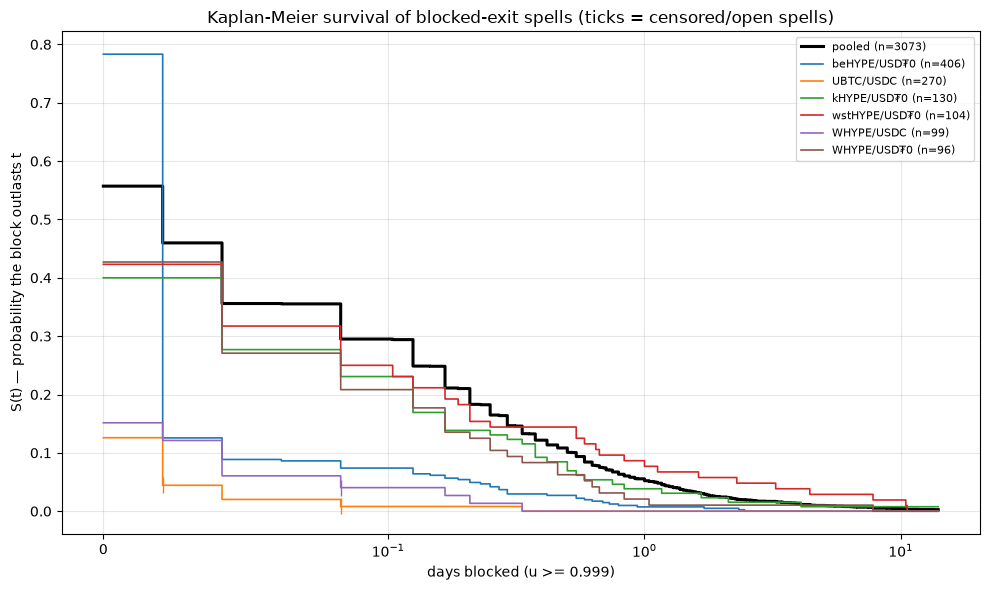

In [9]:
grid = [pd.Timedelta(minutes=m) for m in range(0, 14 * 24 * 60 + 1, 30)]
x_days = [g.total_seconds() / 86400 for g in grid]
fig, ax = plt.subplots(figsize=(10, 6))
pooled_curve = empirical_survival(t999["duration"], t999["observed"], grid)
ax.step(
    x_days,
    pooled_curve.to_numpy(),
    where="post",
    color="black",
    lw=2.2,
    label=f"pooled (n={len(t999)})",
)
top = census.head(6)
for _, mrow in top.iterrows():
    g = t999[t999["market_id"] == mrow["market_id"]]
    curve = empirical_survival(g["duration"], g["observed"], grid)
    ax.step(
        x_days, curve.to_numpy(), where="post", lw=1.2, label=f"{mrow['market']} (n={mrow['n']})"
    )
    cens = g.loc[g["open"], "duration"]
    if len(cens):
        cx = [min(d.total_seconds() / 86400, 14) for d in cens]
        cy = [float(empirical_survival(g["duration"], g["observed"], [d]).iloc[0]) for d in cens]
        ax.plot(cx, cy, "|", ms=12, color=ax.lines[-1].get_color())
ax.set_xlabel("days blocked (u >= 0.999)")
ax.set_ylabel("S(t) — probability the block outlasts t")
ax.set_title("Kaplan-Meier survival of blocked-exit spells (ticks = censored/open spells)")
ax.set_xscale("symlog", linthresh=0.1)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
Path("assets").mkdir(exist_ok=True)
fig.savefig("assets/km_survival.png", dpi=150, bbox_inches="tight")
plt.show()

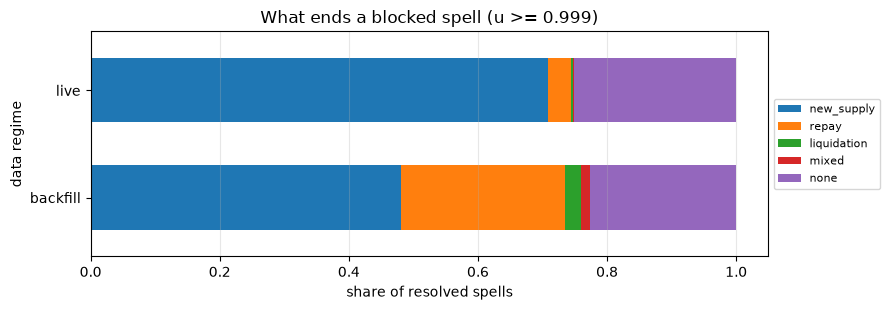

In [10]:
# Resolution-mechanism mix by data regime.
mix = res.groupby("era")["mechanism"].value_counts(normalize=True).unstack(fill_value=0.0)
mix = mix[[c for c in ["new_supply", "repay", "liquidation", "mixed", "none"] if c in mix]]
fig, ax = plt.subplots(figsize=(9, 3.2))
mix.plot.barh(stacked=True, ax=ax, width=0.6)
ax.set_xlabel("share of resolved spells")
ax.set_ylabel("data regime")
ax.set_title("What ends a blocked spell (u >= 0.999)")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
fig.savefig("assets/mechanism_mix.png", dpi=150, bbox_inches="tight")
plt.show()

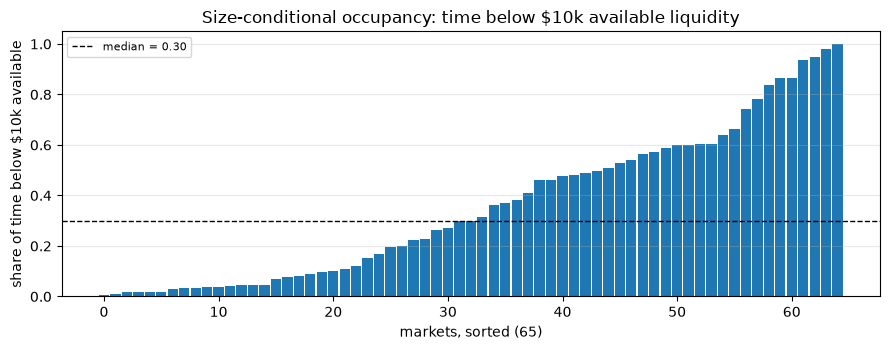

In [11]:
# Occupancy below $10k available liquidity, all priced markets, sorted.
occ_sorted = occupancy.sort_values("occ_below_10k").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(occ_sorted.index, occ_sorted["occ_below_10k"], width=0.9)
med = occ_sorted["occ_below_10k"].median()
ax.axhline(med, color="black", lw=1, ls="--", label=f"median = {med:.2f}")
ax.set_xlabel(f"markets, sorted ({len(occ_sorted)})")
ax.set_ylabel("share of time below $10k available")
ax.set_title("Size-conditional occupancy: time below $10k available liquidity")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
fig.savefig("assets/occupancy_below_10k.png", dpi=150, bbox_inches="tight")
plt.show()